# Introdução

Este documento apresenta a resolução do desafio técnico proposto pela Looqbox, contemplando consultas SQL, desenvolvimento de funções em Python para recuperação de dados e criação de visualizações analíticas.

In [68]:
#importando as bibliotecas necessárias
import pandas as pd
from pandas import date_range
from sqlalchemy import create_engine
from dateutil.parser import parse
import matplotlib.pyplot as plt

# SQL Test

## Conexão com o banco

In [69]:
usuario = 'looqbox-challenge'
senha = 'looq-challenge'
host = '35.199.115.174'       
porta = '3306'           
banco = 'looqbox-challenge'
string_conexao = f"mysql+mysqlconnector://{usuario}:{senha}@{host}:{porta}/{banco}"
engine = create_engine(string_conexao)

## Questão 1 

Pergunta: What are the 10 most expensive products in the company?

In [70]:
query = """SELECT PRODUCT_NAME, PRODUCT_VAL 
FROM `looqbox-challenge`.data_product 
ORDER BY PRODUCT_VAL DESC 
LIMIT 10"""

df = pd.read_sql(query, con=engine)

df.head(10)

,PRODUCT_NAME,PRODUCT_VAL
0,Whisky Escoces THE MACALLAN Ruby Garrafa 700ml...,741.99
1,Whisky Escoces JOHNNIE WALKER Blue Label Garra...,735.90
2,Cafeteira Expresso 3 CORACOES Tres Modo Vermelho,499.00
3,Vinho Portugues Tinto Vintage QUINTA DO CRASTO...,445.90
4,Escova Dental Eletrica ORAL B D34 Professional...,399.90
5,Champagne Rose VEUVE CLICQUOT PONSARDIM Garraf...,366.90
6,Champagne Frances Brut Imperial MOET Rose Garr...,359.90
7,Conjunto de Panelas Allegra em Inox TRAMONTINA...,359.00
8,Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml,329.90
9,Champagne Frances Brut Imperial MOET & CHANDON...,315.90


## Questão 2

Pergunta: What sections do the 'BEBIDAS' and 'PADARIA' departments have?

In [71]:
query = """SELECT DISTINCT DEP_NAME, SECTION_NAME 
FROM `looqbox-challenge`.data_product 
WHERE DEP_NAME IN ('BEBIDAS','PADARIA') 
ORDER BY DEP_NAME"""

df = pd.read_sql(query, con=engine)

df.head(10)

,DEP_NAME,SECTION_NAME
0,BEBIDAS,BEBIDAS
1,BEBIDAS,CERVEJAS
2,BEBIDAS,REFRESCOS
3,BEBIDAS,VINHOS
4,PADARIA,DOCES-E-SOBREMESAS
5,PADARIA,GESTANTE
6,PADARIA,PADARIA
7,PADARIA,QUEIJOS-E-FRIOS


## Questão 3

Pergunta: What was the total sale of products (in $) of each Business Area in the first quarter of 2019?

In [72]:
query = """SELECT BUSINESS_NAME AS Business_Area, SUM(SALES) AS SALES$ FROM
(SELECT BUSINESS_NAME, (SALES_VALUE * SALES_QTY) AS SALES
FROM `looqbox-challenge`.data_product_sales sales 
LEFT JOIN `looqbox-challenge`.data_store_cad store ON sales.STORE_CODE = store.STORE_CODE
WHERE QUARTER(sales.DATE)=1 AND YEAR(sales.DATE)=2019) AS A
GROUP BY BUSINESS_NAME"""

df = pd.read_sql(query, con=engine)

df.head(10)

,Business_Area,SALES$
0,Varejo,1.684404e+10
1,Farma,1.400226e+10
2,Atacado,1.659796e+10
3,Posto,5.347998e+09
4,Proximidade,1.656786e+10


In [73]:
# Fechando conexão com o banco de dados
engine.dispose()

# CASES

## CASE 1

In [74]:
# 1. Configurações de acesso ao banco de dados
usuario = 'looqbox-challenge'
senha = 'looq-challenge'
host = '35.199.115.174' 
porta = '3306'           
banco = 'looqbox-challenge'

string_conexao = f"mysql+mysqlconnector://{usuario}:{senha}@{host}:{porta}/{banco}"
engine = create_engine(string_conexao)

# 2. Função para corrigir as datas e montar a query
def retrieve_data(product_code:int, store_code:int, date:list[str]):
    datas_corrigidas = []

    # 1. LOOP PARA CORREÇÃO AUTOMÁTICA
    for d in date:
        try:        
            data_objeto = parse(d, dayfirst=True)
            
            data_formatada = data_objeto.strftime("%Y-%m-%d")
            datas_corrigidas.append(data_formatada)
            
        except (ValueError, TypeError):
            # Se o texto for algo completamente ilegível (ex: "texto_qualquer")
            raise ValueError(f"Não foi possível entender a data: '{d}'. Digite uma data válida.")

    # 2. MONTAGEM DA QUERY
    query = (f"""SELECT *
            FROM 
                data_product_sales 
            WHERE 
                PRODUCT_CODE = {product_code} AND 
                STORE_CODE = {store_code} AND 
                DATE BETWEEN '{datas_corrigidas[0]}' AND '{datas_corrigidas[1]}' """)
    return pd.read_sql(query, con=engine)

my_data = retrieve_data(10, 10, ['01/01/2019', '2019-01-31'])

# 4. Fechar a conexão
engine.dispose()


In [75]:
my_data.head()

,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY
0,10,10,2019-01-01,2386.15,65.0
1,10,10,2019-01-02,4368.49,119.0
2,10,10,2019-01-03,3854.55,105.0
3,10,10,2019-01-04,3671.00,100.0
4,10,10,2019-01-05,3010.22,82.0


## CASE 2

In [76]:
# 1. Configurações de acesso ao banco de dados
usuario = 'looqbox-challenge'
senha = 'looq-challenge'
host = '35.199.115.174'      
porta = '3306'           
banco = 'looqbox-challenge'

string_conexao = f"mysql+mysqlconnector://{usuario}:{senha}@{host}:{porta}/{banco}"
engine = create_engine(string_conexao)

# 2. Consultas SQL para ler as tabelas
query1 = """SELECT
      STORE_CODE,
      STORE_NAME,
      START_DATE,
      END_DATE,
      BUSINESS_NAME,
      BUSINESS_CODE
FROM data_store_cad"""

query2 = """SELECT
        STORE_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'"""

# 3. Ler as tabelas usando as consultas SQL e armazenar em DataFrames do Pandas
df1 = pd.read_sql(query1, con=engine)
df2 = pd.read_sql(query2, con=engine)

# 4. Fechar a conexão
engine.dispose()

In [77]:
df1.head()

,STORE_CODE,STORE_NAME,START_DATE,END_DATE,BUSINESS_NAME,BUSINESS_CODE
0,1,Sao Paulo,2006-10-01,,Varejo,1
1,2,Chicago,2007-10-01,,Varejo,1
2,3,Roma,2008-10-01,,Varejo,1
3,4,Tokio,2009-10-01,,Varejo,1
4,5,Paris,2019-01-01,,Proximidade,2


In [78]:
df2.head()

,STORE_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,2019-01-01,196623.22,12838
1,10,2019-01-01,126795.44,4933
2,11,2019-01-01,223937.00,7724
3,12,2019-01-01,200251.80,7043
4,13,2019-01-01,196623.22,12838


In [79]:
# 5. transformar a coluna 'DATE' para o formato datetime e filtrar as datas
df2['DATE'] = pd.to_datetime(df2['DATE'])
df2 = df2[(df2['DATE'] >= '2019-10-01') & (df2['DATE'] <= '2019-12-31')]

# Agrupar por STORE_CODE e calcular o Ticket Médio
df2 = df2.groupby('STORE_CODE').agg({'SALES_VALUE':'sum', 'SALES_QTY':'sum'}).reset_index()
df2['TM'] = df2['SALES_VALUE'] / df2['SALES_QTY']
df2['TM'] = df2['TM'].round(2)

In [80]:
# 6. Fazer o merge entre os DataFrames df1 e df2 usando a coluna 'STORE_CODE' como chave
tm = df1.merge(df2,
                  left_on='STORE_CODE',
                  right_on='STORE_CODE',
                  how='left')

In [81]:
tm.head()

,STORE_CODE,STORE_NAME,START_DATE,END_DATE,BUSINESS_NAME,BUSINESS_CODE,SALES_VALUE,SALES_QTY,TM
0,1,Sao Paulo,2006-10-01,,Varejo,1,21213088.57,1378476,15.39
1,2,Chicago,2007-10-01,,Varejo,1,21928421.28,1412372,15.53
2,3,Roma,2008-10-01,,Varejo,1,21213088.57,1378476,15.39
3,4,Tokio,2009-10-01,,Varejo,1,21213088.57,1378476,15.39
4,5,Paris,2019-01-01,,Proximidade,2,21213088.57,1378476,15.39


In [82]:
# Transformações finais para exibição do resultado
tm = tm.rename(columns={'STORE_NAME':'Loja','BUSINESS_NAME':'Categoria'})
tm = tm[['Loja','Categoria','TM']]
tm = tm.sort_values(by='Loja')
tm['TM'] = tm['TM'].map('{:.2f}'.format).str.replace('.', ',', regex=False) #Feito com IA

tm.head(20)

,Loja,Categoria,TM
13,Bahia,Atacado,"15,39"
17,Bangkok,Posto,"13,67"
7,Belem,Proximidade,"15,37"
5,Berlin,Proximidade,"15,39"
14,Buenos Aires,Atacado,"15,39"
1,Chicago,Varejo,"15,53"
12,Dubai,Atacado,"15,39"
9,Hong Kong,Farma,"26,35"
8,London,Farma,"28,99"
11,Madri,Farma,"29,03"


## Case 3

In [83]:
# 1. Configurações de acesso ao banco de dados
usuario = 'looqbox-challenge'
senha = 'looq-challenge'
host = '35.199.115.174'       
porta = '3306'           
banco = 'looqbox-challenge'
string_conexao = f"mysql+mysqlconnector://{usuario}:{senha}@{host}:{porta}/{banco}"
engine = create_engine(string_conexao)

# 2. Criando query para ler a tabela IMDB_movies
query = """SELECT* FROM IMDB_movies"""

df = pd.read_sql(query, con=engine)

# 3. Fechar a conexão
engine.dispose()

In [84]:
df.head()

,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0
2,3,Split,"Horror,Thriller",M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.0,157606,138.0,62.0
3,4,Sing,"Animation,Comedy,Family",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.0,60545,270.0,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.0,393727,325.0,40.0


In [85]:
# Criação de média para gráfico de linha
media_ano = df.groupby('Year').agg({'Rating':'mean'}).reset_index()
media_ano.head()

,Year,Rating
0,2006,7.272727
1,2007,7.207547
2,2008,6.846154
3,2009,7.058824
4,2010,6.883333


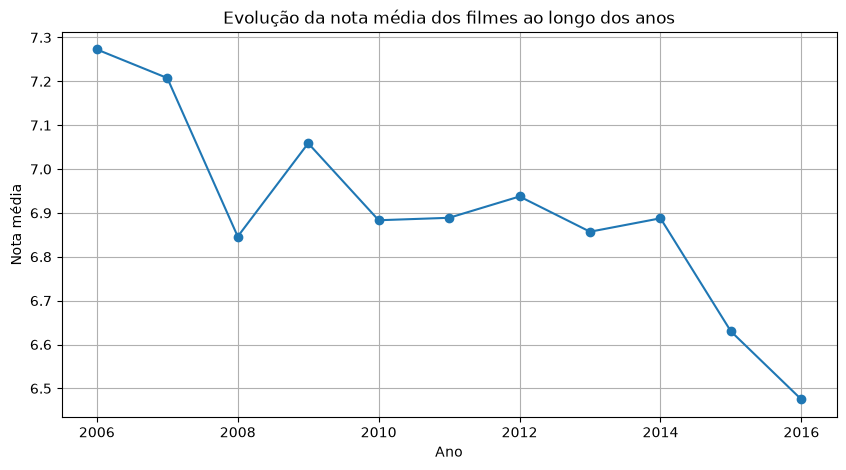

In [86]:
# Criação do gráfico de linha
plt.figure(figsize=(10,5))
plt.plot(
    media_ano["Year"],
    media_ano["Rating"],
    marker="o"
)
plt.title("Evolução da nota média dos filmes ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Nota média")
plt.grid(True)

plt.show()

In [87]:
# Buscando o gênero principal de cada filme (o primeiro da lista de gêneros)
df["Main_Genre"] = df["Genre"].str.split(",").str[0]

# Criação de média para gráfico de barras
receita_genero = df.groupby('Main_Genre').agg({'RevenueMillions':'mean'}).reset_index().sort_values("RevenueMillions", ascending=False)
receita_genero.head()

,Main_Genre,RevenueMillions
2,Animation,191.170213
0,Action,122.101449
1,Adventure,113.422535
9,Mystery,64.454545
7,Fantasy,63.000000


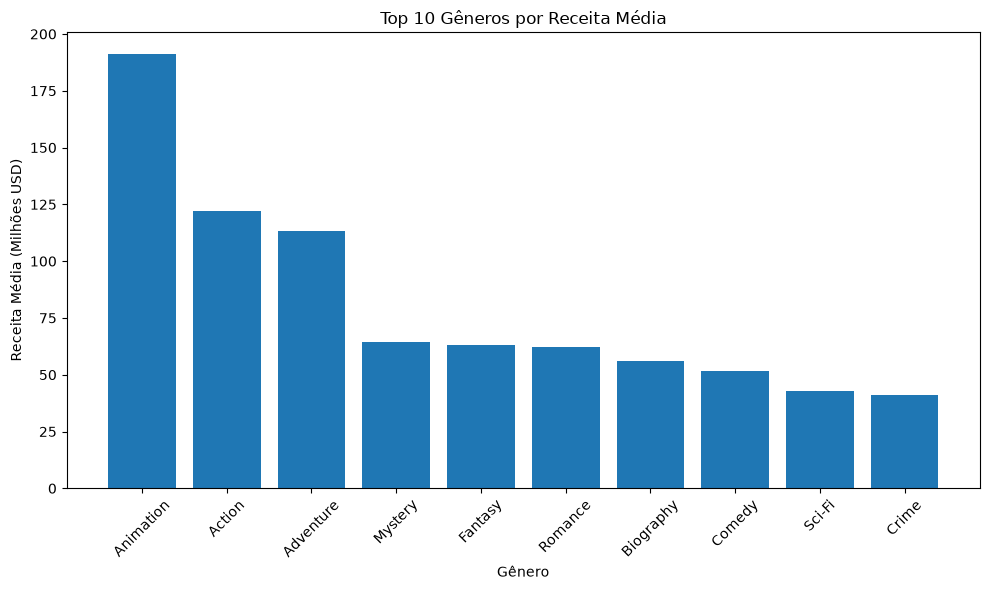

In [88]:
# Selecionando os 10 gêneros com maior receita média
top10 = receita_genero.head(10)

# Criação do gráfico de barras
plt.figure(figsize=(10,6))

plt.bar(
    top10["Main_Genre"],
    top10["RevenueMillions"]
)
plt.title("Top 10 Gêneros por Receita Média")
plt.xlabel("Gênero")
plt.ylabel("Receita Média (Milhões USD)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Uso de IA 

Durante a realização do desafio, utilizei ferramentas de Inteligência Artificial como apoio pontual para esclarecer dúvidas específicas e acelerar algumas etapas de desenvolvimento. A IA foi utilizada principalmente para: 

Ajudar na conexão com o banco de dados 

Auxiliar na implementação da validação e padronização de datas no Case 1; 

Revisar e gerar comentários de código em alguns trechos da solução; 

Ajudar na interpretação da sigla "TM" no Case 2, sugerindo que poderia representar Ticket Médio; 

Auxiliar na formatação final dos valores da coluna TM para o padrão apresentado no desafio; 

Esclarecer dúvidas sobre filtros de datas em SQL; 

Apoiar a extração do gênero principal da coluna Genre no Case 3; 

Auxiliar na configuração de alguns parâmetros de visualização utilizando Matplotlib. 

Revisar os erros ortográficos no PDF 

 

Toda a lógica de negócio, modelagem das consultas SQL, definição das transformações, estruturação das soluções, interpretação dos dados, criação dos gráficos e validação dos resultados foram realizadas por mim. A IA foi utilizada como uma ferramenta de apoio técnico, semelhante ao uso de documentação, fóruns ou materiais de consulta, e não como substituta do raciocínio utilizado na resolução do desafio.